<a href="https://colab.research.google.com/github/jeeva477/NLP/blob/main/NLP_Project_%24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [8]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
spam_emails = [
    "Congratulations! You have won a ₹25,000 Amazon gift card. Claim now!",
    "Your account has been suspended. Verify your details immediately.",
    "Exclusive offer! Get 80% OFF on all electronics. Shop today!",
    "You have been selected as the lucky winner of a brand new iPhone.",
    "Earn ₹10,000 per day working from home. Limited vacancies!",
    "URGENT: Your bank account requires verification. Click the link below.",
    "Free vacation package to Goa! Book your prize before midnight.",
    "Claim your cashback reward of ₹5,000 now. Offer expires today.",
    "You have received an unexpected tax refund. Confirm your account details.",
    "Congratulations! Your mobile number has won a cash prize of ₹1,00,000.",
    "Get instant approval for a personal loan with zero documentation.",
    "Limited Time Deal! Buy one, get three free. Order now!",
    "Your PayPal account has unusual activity. Login to secure it.",
    "Congratulations! You are selected for a free laptop giveaway.",
    "Act fast! This investment can double your money in just one week.",
    "Your parcel is waiting for delivery. Pay a small fee to receive it.",
    "Claim your free movie tickets before the offer expires.",
    "Final reminder! Update your KYC to avoid account suspension.",
    "Win exciting cash rewards by completing this short survey.",
    "Special discount just for you! Save 90% on premium memberships."
]

In [10]:
a_emails = [
    "Hi Jeeva, hope you're doing well. Let's meet after class today.",
    "Your assignment has been submitted successfully.",
    "The project review meeting is scheduled for tomorrow at 11:00 AM.",
    "Please find the attached report for your reference.",
    "Your order has been delivered successfully. Thank you for shopping with us.",
    "Reminder: The Machine Learning class starts at 9:30 AM tomorrow.",
    "Your library books are due for return on Friday.",
    "The interview has been confirmed for Monday at 2:00 PM.",
    "Please upload your presentation slides before today's meeting.",
    "Your semester examination timetable has been published.",
    "Thank you for attending today's workshop.",
    "The faculty meeting has been postponed to next Wednesday.",
    "Your attendance has been updated in the student portal.",
    "Can we discuss the project after lunch?",
    "The payment for your course has been received successfully.",
    "Please review the document and share your feedback.",
    "Your package is out for delivery and will arrive today.",
    "The lab session has been shifted to Room 204.",
    "Happy Birthday! Wishing you a wonderful year ahead.",
    "Don't forget to bring your ID card for tomorrow's exam."
]

In [11]:
import random

random.seed(42)

data = []

for i in range(1000):

    # 50% spam and 50% ham
    if i < 500:

        # 85% correct spam emails
        if random.random() < 0.85:
            email = random.choice(spam_emails)
        else:
            # 15% confusing normal-looking emails
            email = random.choice(a_emails)

        label = "spam"

    else:

        # 85% correct ham emails
        if random.random() < 0.85:
            email = random.choice(a_emails)
        else:
            # 15% confusing spam-looking emails
            email = random.choice(spam_emails)

        label = "a"

    data.append([email, label])

In [12]:

df = pd.DataFrame(
    data,
    columns=["Email", "Label"]
)

# Shuffle all rows randomly
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)
df.head(10)



,Email,Label
0,Please upload your presentation slides before ...,a
1,Don't forget to bring your ID card for tomorro...,a
2,The interview has been confirmed for Monday at...,a
3,The payment for your course has been received ...,a
4,Get instant approval for a personal loan with ...,spam
5,Your order has been delivered successfully. Th...,a
6,The lab session has been shifted to Room 204.,a
7,Your assignment has been submitted successfully.,a
8,Reminder: The Machine Learning class starts at...,a
9,Win exciting cash rewards by completing this s...,spam


In [13]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 2)


In [14]:
df["Label"].value_counts()

,count
Label,
a,500
spam,500


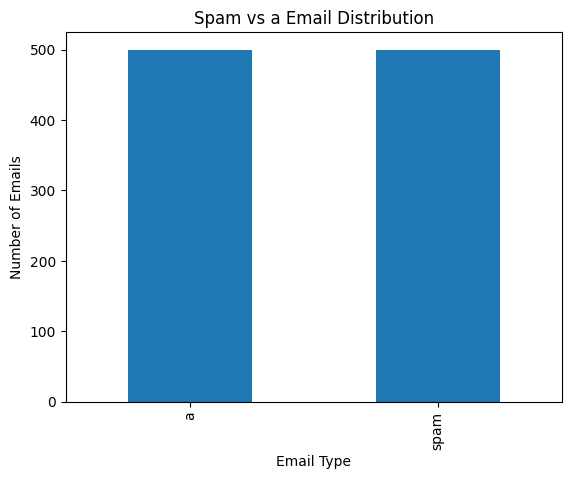

In [16]:
df["Label"].value_counts().plot(kind="bar")
plt.title("Spam vs a Email Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.show()

In [17]:
df.isnull().sum()

,0
Email,0
Label,0


In [18]:
df.duplicated().sum()

np.int64(922)

In [19]:
def clean_text(text):

    # Convert uppercase letters to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'www\.\S+|https?://\S+', '', text)

    # Remove numbers and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [20]:
df["Clean_Email"] = df["Email"].apply(clean_text)

df.head(10)

,Email,Label,Clean_Email
0,Please upload your presentation slides before ...,a,please upload your presentation slides before ...
1,Don't forget to bring your ID card for tomorro...,a,dont forget to bring your id card for tomorrow...
2,The interview has been confirmed for Monday at...,a,the interview has been confirmed for monday at pm
3,The payment for your course has been received ...,a,the payment for your course has been received ...
4,Get instant approval for a personal loan with ...,spam,get instant approval for a personal loan with ...
5,Your order has been delivered successfully. Th...,a,your order has been delivered successfully tha...
6,The lab session has been shifted to Room 204.,a,the lab session has been shifted to room
7,Your assignment has been submitted successfully.,a,your assignment has been submitted successfully
8,Reminder: The Machine Learning class starts at...,a,reminder the machine learning class starts at ...
9,Win exciting cash rewards by completing this s...,spam,win exciting cash rewards by completing this s...


In [21]:
for i in range(5):

    print("Original Email:")
    print(df["Email"].iloc[i])

    print("\nCleaned Email:")
    print(df["Clean_Email"].iloc[i])

    print("-" * 70)


Original Email:
Please upload your presentation slides before today's meeting.

Cleaned Email:
please upload your presentation slides before todays meeting
----------------------------------------------------------------------
Original Email:
Don't forget to bring your ID card for tomorrow's exam.

Cleaned Email:
dont forget to bring your id card for tomorrows exam
----------------------------------------------------------------------
Original Email:
The interview has been confirmed for Monday at 2:00 PM.

Cleaned Email:
the interview has been confirmed for monday at pm
----------------------------------------------------------------------
Original Email:
The payment for your course has been received successfully.

Cleaned Email:
the payment for your course has been received successfully
----------------------------------------------------------------------
Original Email:
Get instant approval for a personal loan with zero documentation.

Cleaned Email:
get instant approval for a perso

In [22]:
X = df["Clean_Email"]
y = df["Label"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print("Training Emails:", len(X_train))
print("Testing Emails :", len(X_test))

Training Emails: 800
Testing Emails : 200


In [25]:
tfidf = TfidfVectorizer(
    stop_words="english"
)

In [26]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [27]:

print("Training TF-IDF Shape:", X_train_tfidf.shape)

print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (800, 176)
Testing TF-IDF Shape: (200, 176)


In [28]:

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [29]:
y_pred = model.predict(X_test_tfidf)

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Model Accuracy: 85.0 %


In [31]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[86 14]
 [16 84]]


In [32]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

           a       0.84      0.86      0.85       100
        spam       0.86      0.84      0.85       100

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



In [33]:
total_emails = len(df)

total_spam = (df["Label"] == "spam").sum()

total_ham = (df["Label"] == "ham").sum()

spam_percentage = (
    total_spam / total_emails
) * 100

ham_percentage = (
    total_ham / total_emails
) * 100

model_accuracy = accuracy * 100

In [34]:
print("=" * 60)

print("          EMAIL SPAM DETECTION ANALYSIS REPORT")

print("=" * 60)


print("\n1. DATASET ANALYSIS")

print("-" * 60)

print("Total Emails          :", total_emails)

print("Total Spam Emails     :", total_spam)

print("Total Ham Emails      :", total_ham)

print(
    "Spam Percentage       :",
    round(spam_percentage, 2),
    "%"
)

print(
    "Ham Percentage        :",
    round(ham_percentage, 2),
    "%"
)


print("\n2. PREPROCESSING ANALYSIS")

print("-" * 60)

print("Text converted to lowercase")

print("URLs removed")

print("Numbers removed")

print("Special characters removed")

print("Extra spaces removed")


print("\n3. MODEL INFORMATION")

print("-" * 60)

print("Model Used            : Multinomial Naive Bayes")

print("Feature Extraction    : TF-IDF")

print("Training Emails       :", len(X_train))

print("Testing Emails        :", len(X_test))


print("\n4. MODEL PERFORMANCE")

print("-" * 60)

print(
    "Model Accuracy        :",
    round(model_accuracy, 2),
    "%"
)


print("\n5. FINAL ANALYSIS")

print("-" * 60)


if 80 <= model_accuracy <= 90:

    print(
        "The model achieved good accuracy "
        "between 80% and 90%."
    )

elif model_accuracy > 90:

    print(
        "The model achieved very high accuracy."
    )

else:

    print(
        "The model needs further improvement."
    )


print("\n" + "=" * 60)

print("                 END OF ANALYSIS REPORT")

print("=" * 60)

          EMAIL SPAM DETECTION ANALYSIS REPORT

1. DATASET ANALYSIS
------------------------------------------------------------
Total Emails          : 1000
Total Spam Emails     : 500
Total Ham Emails      : 0
Spam Percentage       : 50.0 %
Ham Percentage        : 0.0 %

2. PREPROCESSING ANALYSIS
------------------------------------------------------------
Text converted to lowercase
URLs removed
Numbers removed
Special characters removed
Extra spaces removed

3. MODEL INFORMATION
------------------------------------------------------------
Model Used            : Multinomial Naive Bayes
Feature Extraction    : TF-IDF
Training Emails       : 800
Testing Emails        : 200

4. MODEL PERFORMANCE
------------------------------------------------------------
Model Accuracy        : 85.0 %

5. FINAL ANALYSIS
------------------------------------------------------------
The model achieved good accuracy between 80% and 90%.

                 END OF ANALYSIS REPORT


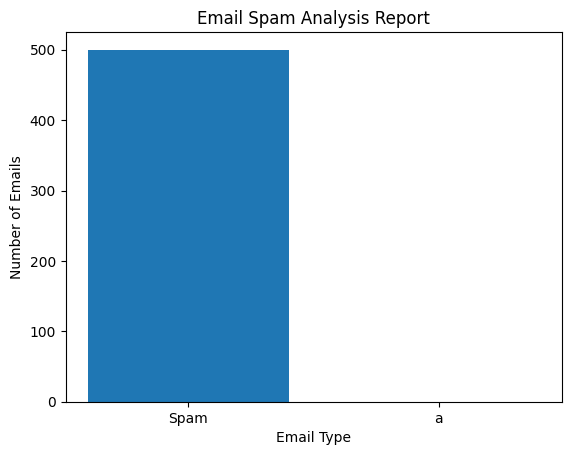

In [37]:
report_data = pd.DataFrame({
    "Email Type": ["Spam", "a"],
    "Count": [total_spam, total_ham]
})

plt.bar(
    report_data["Email Type"],
    report_data["Count"]
)

plt.title("Email Spam Analysis Report")

plt.xlabel("Email Type")

plt.ylabel("Number of Emails")

plt.show()

In [38]:
def predict_email(email):

    # Clean the email
    cleaned_email = clean_text(email)

    # Convert into TF-IDF
    email_tfidf = tfidf.transform(
        [cleaned_email]
    )

    # Predict
    prediction = model.predict(
        email_tfidf
    )[0]

    return prediction

In [40]:
new_email = """
CONGRATULATIONS!!!
You WON I phone!!
Click NOW!!!
"""

prediction = predict_email(new_email)

print("Email      :", new_email)

print("Prediction :", prediction)

Email      : 
CONGRATULATIONS!!!
You WON I phone!!
Click NOW!!!

Prediction : spam


In [41]:
new_email = (
    "Hi Jeeva, tomorrow we have A meeting at 12."
)
prediction = predict_email(new_email)

print("Email      :", new_email)

print("Prediction :", prediction)

Email      : Hi Jeeva, tomorrow we have A meeting at 12.
Prediction : a
